In [38]:
'''Use sklearn's PolynomialFeatures() to transform a dataset of mobile phone prices (features: RAM, storage) into polynomial features up to degree 2,
and print the resulting feature matrix.'''

import numpy as np
import pandas as pd

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score

data=pd.read_csv('mobile_phone.csv')
data.head()

,Brand,RAM_GB,Storage_GB,Camera_MP,Battery_mAh,Price_INR
0,Samsung,12,256,12,5000,59200
1,Realme,12,1024,64,5000,90500
2,Oppo,16,128,200,3000,55300
3,OnePlus,8,256,108,5000,48300
4,OnePlus,8,512,50,5000,64700


In [39]:
x=data[['RAM_GB','Storage_GB']]
y=data['Price_INR']

x_train,x_test,y_train,y_test=train_test_split(
    x,
    y,
    train_size=0.80,
    random_state=42
)

In [40]:
model=PolynomialFeatures(degree=2)         # "Take my existing features and create polynomial terms up to power 2."
x_train=model.fit_transform(x_train)      # fit → learns the structure of the input features. transform → creates the polynomial features.
x_test=model.transform(x_test)           # this transform apply what was learned from fit_transform to this x_test.

In [41]:
lr=LinearRegression()         # Now we create the actual regression model.
lr.fit(x_train,y_train)       # here it is like model,fit(x_train,y_train)
pre=lr.predict(x_test)        # here it is like model.predict(x_test)
pre

array([ 50712.18178842,  44101.23950684,  50712.18178842,  45883.57672955,
        50712.18178842,  41202.6125252 ,  44101.23950684,  66243.09102371,
        41202.6125252 ,  44101.23950684,  54413.36419312,  73073.41763378,
        44101.23950684,  51585.16373652,  66243.09102371,  51585.16373652,
        41202.6125252 ,  54413.36419312,  92168.13906282,  48598.75551332,
        41202.6125252 ,  65935.78790278,  45883.57672955,  44101.23950684,
        81295.96512251,  58371.66850124,  50712.18178842,  81295.96512251,
        66243.09102371,  44101.23950684,  44101.23950684,  58371.66850124,
        34843.88107309,  48598.75551332,  50712.18178842,  92168.13906282,
        66243.09102371,  66243.09102371,  59883.07592952,  65935.78790278,
        73073.41763378,  50712.18178842,  66243.09102371,  44101.23950684,
        58371.66850124,  48598.75551332,  65935.78790278,  44101.23950684,
        34843.88107309,  44101.23950684,  73073.41763378,  51585.16373652,
        41202.6125252 ,  

In [42]:
r2=r2_score(y_test,pre)
r2

0.558317616892819

In [43]:
'''
Train both a LinearRegression and a Polynomial Regression (degree=3) model on a dataset of Zomato restaurant ratings 
versus number of reviews, then plot both predictions on the same chart to compare their fits.<br><br><em><strong>
Hint:</strong> Use matplotlib for plotting and clearly label both curves.</em>'''

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

In [44]:
df=pd.read_excel('zomato.xlsx')
df.head()

,no.,restaurant_rating,no_of_reviews
0,1,4.5,1000
1,2,3.2,2000
2,3,1.9,1200
3,4,5.0,1100
4,5,4.8,1020


In [45]:
x=df[['restaurant_rating']]
y=df[['no_of_reviews']]

In [55]:
x_train,x_test,y_train,y_test=train_test_split(
    x,
    y,
    train_size=0.80,
    random_state=42
)

model1=LinearRegression()
model1.fit(x_train,y_train)
pre1=model1.predict(x_test)
pre1

array([[2661.34442857],
       [2050.31717741],
       [2716.89236049],
       [2355.83080299],
       [2133.6390753 ],
       [1966.99527953],
       [1994.76924549],
       [2272.50890511],
       [3272.37167972],
       [1883.67338164]])

In [54]:
model2=PolynomialFeatures(degree=3)
x_train1=model2.fit_transform(x_train)
x_test1=model2.transform(x_test)

lr=LinearRegression()
lr.fit(x_train1,y_train)
pre2=lr.predict(x_test1)
pre2

array([[2356.97052345],
       [2149.65157203],
       [2365.06974279],
       [2567.53682305],
       [2409.1832887 ],
       [1734.94807009],
       [1892.24925824],
       [2577.2265937 ],
       [5881.47085599],
       [1135.50165875]])

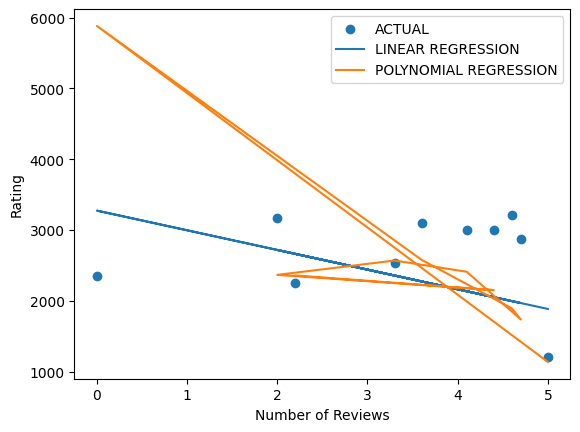

In [57]:
import matplotlib.pyplot as plt

plt.scatter(x_test,y_test,label='ACTUAL')
plt.plot(x_test,pre1,label='LINEAR REGRESSION')
plt.plot(x_test,pre2,label='POLYNOMIAL REGRESSION')

plt.xlabel("Number of Reviews")
plt.ylabel("Rating")

plt.legend()
plt.show()

In [60]:
'''Given a dataset where the relationship between followers and posts for Instagram users is non-linear, 
fit a polynomial regression model (degree=4) and check for overfitting by plotting the training and validation errors for degrees 1 to 5.'''

import numpy as np

followers = np.array([
    500, 800, 1200, 1800, 2500, 3200, 4000, 5000, 6500, 8000,
    10000, 12500, 15000, 18000, 22000, 26000, 30000, 35000, 40000, 46000,
    52000, 60000, 70000, 80000, 90000, 105000, 120000, 140000, 160000, 185000
]).reshape(-1,1)

posts = np.array([
    35, 43, 51, 62, 75, 88, 103, 120, 142, 168,
    195, 225, 260, 300, 345, 395, 450, 510, 575, 645,
    720, 805, 900, 1005, 1120, 1250, 1390, 1540, 1705, 1880
])

In [61]:
x_train2, x_test2, y_train2, y_test2 = train_test_split(
    followers, posts, test_size=0.2, random_state=42
)

In [65]:
train_error=[]
test_error=[]

for degree in range(1,6):
    poly=PolynomialFeatures(degree)
    
    x_train_poly=poly.fit_transform(x_train2)
    x_test_poly=poly.transform(x_test2)
    
    model=LinearRegression()
    model.fit(x_train_poly,y_train2)
    
    pre_train=model.predict(x_train_poly)        # we are taking this 2 pre_train and pre_test bcz we are checking for overfitting.
    pre_test=model.predict(x_test_poly)

    train_error.append(r2_score(y_train2,pre_train))
    test_error.append(r2_score(y_test2,pre_test))


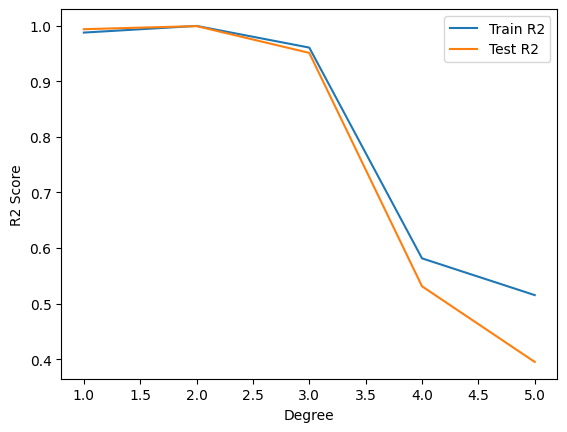

In [67]:
plt.plot(range(1, 6), train_error, label="Train R2")
plt.plot(range(1, 6), test_error, label="Test R2")

plt.xlabel("Degree")
plt.ylabel("R2 Score")
plt.legend()
plt.show()

In [ ]:
'''graph shows performance getting worse as degree increases, especially on test data, 
but it does not show the usual overfitting pattern.'''

In [1]:
'''Add L2 regularization (Ridge regression) to your polynomial regression model (degree=3) on a Flipkart product price prediction dataset, 
and compare the model's performance with and without regularization.<br><br><em><strong>Hint:</strong> Use Ridge from 
sklearn.linear_model and explain any difference in test error.</em>'''

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score

# Polynomial features
poly = PolynomialFeatures(degree=3)

x_train_poly = poly.fit_transform(x_train)
x_test_poly = poly.transform(x_test)


# ---------------- WITHOUT REGULARIZATION ----------------

model1 = LinearRegression()

model1.fit(x_train_poly, y_train)

pred_train1 = model1.predict(x_train_poly)
pred_test1 = model1.predict(x_test_poly)

print("WITHOUT REGULARIZATION")
print("Train MSE:", mean_squared_error(y_train, pred_train1))
print("Test MSE :", mean_squared_error(y_test, pred_test1))
print("Train R2 :", r2_score(y_train, pred_train1))
print("Test R2  :", r2_score(y_test, pred_test1))


# ---------------- WITH RIDGE ----------------

model2 = Ridge(alpha=1)

model2.fit(x_train_poly, y_train)

pred_train2 = model2.predict(x_train_poly)
pred_test2 = model2.predict(x_test_poly)

print("\nWITH RIDGE REGULARIZATION")

print("Train MSE:", mean_squared_error(y_train, pred_train2))
print("Test MSE :", mean_squared_error(y_test, pred_test2))
print("Train R2 :", r2_score(y_train, pred_train2))
print("Test R2  :", r2_score(y_test, pred_test2))

NameError: name 'x_train' is not defined

In [ ]:
'''Use ChatGPT or Copilot to generate Python code that demonstrates underfitting and overfitting using polynomial regression on a synthetic dataset, 
then run the code and explain in your own words how model degree affects bias and variance.'''

import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Fixed data
x = np.array([1, 2, 3, 4, 5, 6, 7, 8]).reshape(-1, 1)

y = np.array([2, 5, 10, 17, 26, 37, 50, 65])

# ---------------- DEGREE 1 ----------------

poly1 = PolynomialFeatures(degree=1)

x1 = poly1.fit_transform(x)

model1 = LinearRegression()
model1.fit(x1, y)

pred1 = model1.predict(x1)

print("DEGREE 1")
print("MSE :", mean_squared_error(y, pred1))


# ---------------- DEGREE 2 ----------------

poly2 = PolynomialFeatures(degree=2)

x2 = poly2.fit_transform(x)

model2 = LinearRegression()
model2.fit(x2, y)

pred2 = model2.predict(x2)

print("\nDEGREE 2")
print("MSE :", mean_squared_error(y, pred2))


# ---------------- DEGREE 10 ----------------

poly10 = PolynomialFeatures(degree=10)

x10 = poly10.fit_transform(x)

model10 = LinearRegression()
model10.fit(x10, y)

pred10 = model10.predict(x10)

print("\nDEGREE 10")
print("MSE :", mean_squared_error(y, pred10))